# データサイエンス実践

2026年1月29日

氏名： 下澤悠佑

学籍番号： 2252130033 / 名列番号： 118

# 分析の目的・意図
本分析では、白と赤のヴィーニョ・ヴェルデ（ポルトガル産）のワインデータを用いて、
ワインの物理化学的指標が，人による品質評価にどのような影響を与えているのかを明らかにすることを目的とする。

まず、仮説検定では、赤ワインと白ワインの品質評価（quality）に統計的に有意な差が存在するかを確認することを目的とする。
ワインの種類（赤・白）は、製造工程や成分構成が異なるため、官能評価としての品質にも違いが現れる可能性があると考えられる。
そこで、赤ワインと白ワインの品質スコアの平均値を比較し、ワインの種類によって品質評価に有意な差があるかを仮説検定によって検証する。

次に、ワインの品質評価に影響を与える要因をより詳細に分析するため、回帰分析を行う。
被説明変数を品質評価（quality）とし、説明変数としてワインの種類および化学的特性を用いることで、各変数が品質評価にどのような関係を持つかを検討する。




[参考]
- Modeling wine preferences by data mining from physicochemical properties[Cortez et al., 2009] https://www.sciencedirect.com/science/article/pii/S0167923609001377?via=ihub
- UCI Wine Quality: https://archive.ics.uci.edu/dataset/186/wine%2Bquality

## 0. ライブラリ読み込み

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import statsmodels.formula.api as smf
import statsmodels.api as sm


## 1. 変数名の定義と単位

1～11 : 物理化学試験 <br>
12 : 官能検査


1. fixed acidity : 不揮発酸（酒石酸換算, g/dm^3）
2. volatile acidity : 揮発酸（酢酸換算, g/dm^3）
3. citric acid : クエン酸（g/dm^3）
4. residual sugar : 残糖（g/dm^3）
5. chlorides : 塩化物（塩化ナトリウム換算, g/dm^3）
6. free sulfur dioxide : 遊離亜硫酸（mg/dm^3）
7. total sulfur dioxide : 総亜硫酸（mg/dm^3）
8. density : 密度（g/cm^3）
9. pH : pH（無次元）
10. sulphates : 硫酸塩（硫酸カリウム換算, g/dm^3）
11. alcohol : アルコール（体積百分率, vol.%）
12. quality : 品質評価（官能評価スコア, 整数0～10）


In [ ]:
# UCIの公開URL
URL_RED = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
URL_WHITE = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red = pd.read_csv(URL_RED, sep=";")
white = pd.read_csv(URL_WHITE, sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


### データの形と欠損チェック

In [ ]:
print("shape:", df.shape)
display(df.isna().sum())
display(df.describe(include="all"))

shape: (6497, 13)


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,white
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4898
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,NaN
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,NaN
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,NaN
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,NaN
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,NaN
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,NaN


## 2. (1) 変数間の大まかな関係
ここでは以下を行います。
- wine_type（赤/白）でそれぞれの散布図

目的変数は quality（品質スコア） とします。

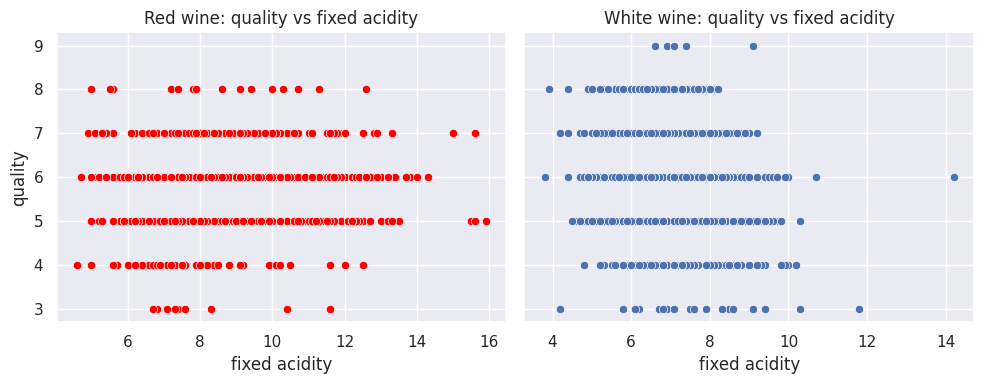

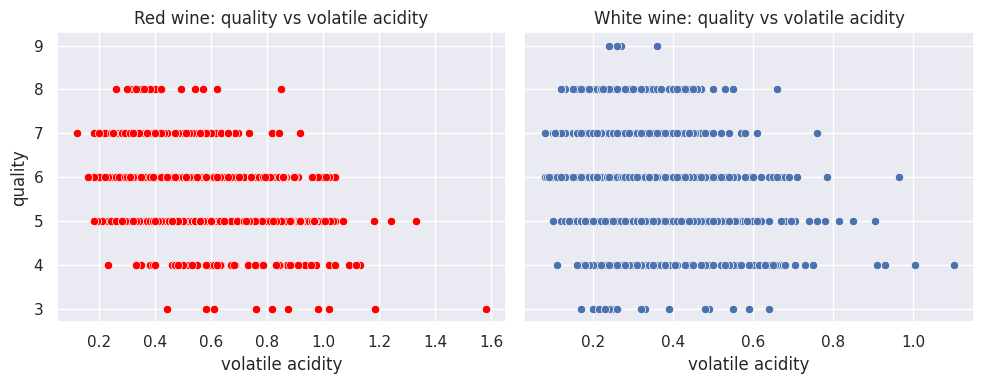

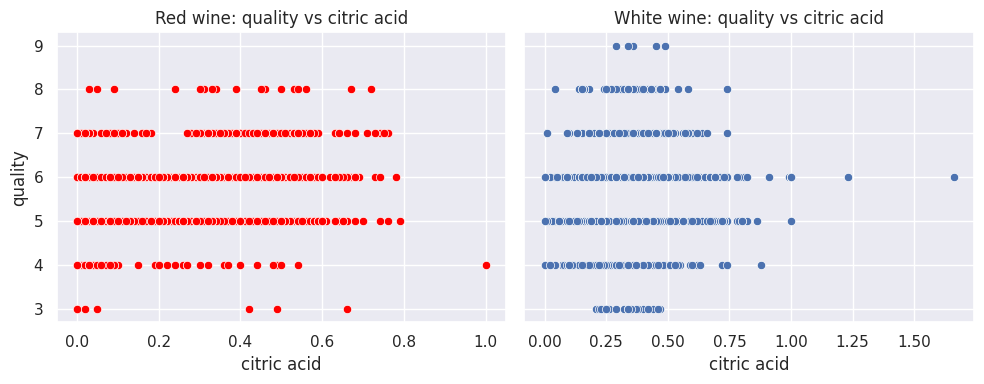

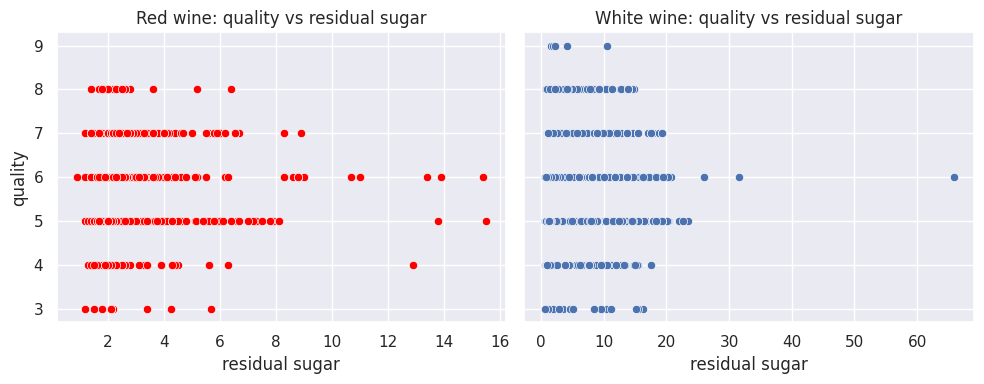

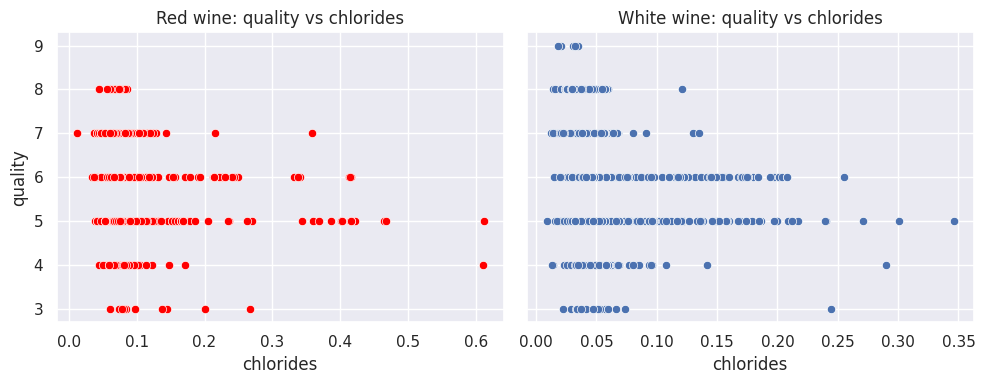

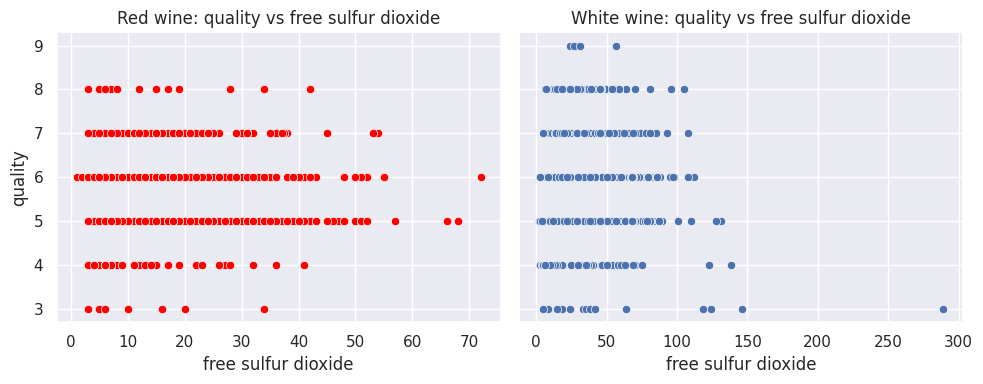

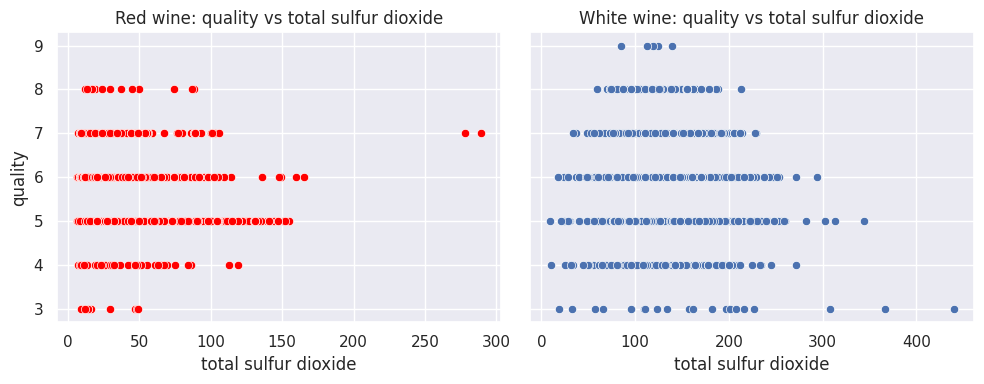

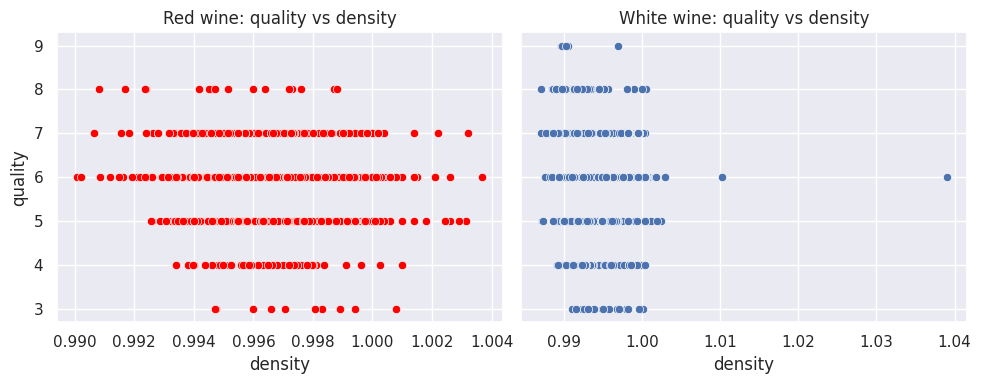

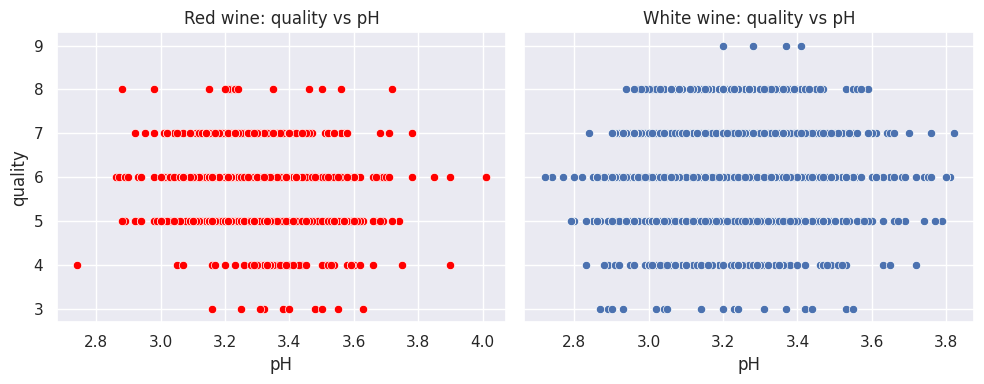

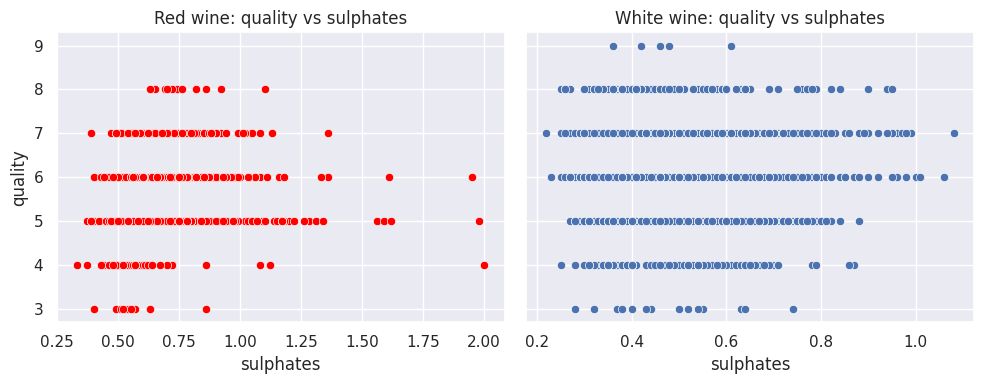

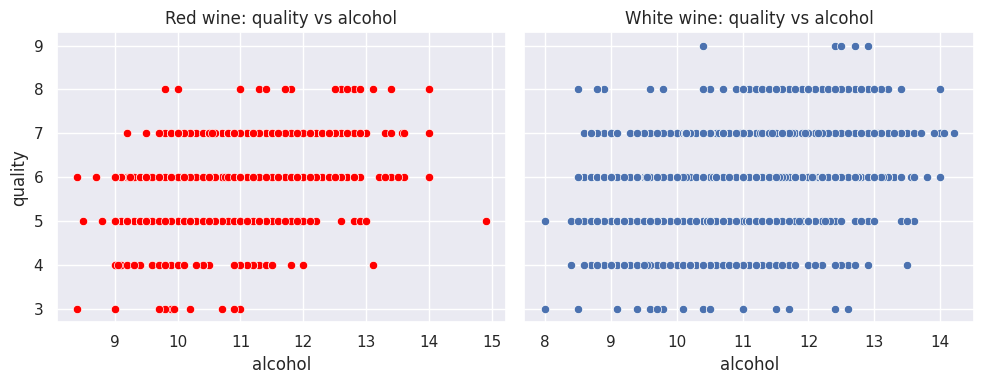

In [ ]:
num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    if col == "quality":
        continue

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    sns.scatterplot(
        data=df[df["wine_type"] == "red"],
        x=col, y="quality", color="red",
        ax=axes[0]
    )
    axes[0].set_title(f"Red wine: quality vs {col}")

    sns.scatterplot(
        data=df[df["wine_type"] == "white"],
        x=col, y="quality",
        ax=axes[1]
    )
    axes[1].set_title(f"White wine: quality vs {col}")

    plt.tight_layout()
    plt.show()



### 散布図から言えること
- alcohol が高いほど quality が高くなる傾向（正の相関）
- volatile acidity が高いほど quality が下がる傾向（負の相関）
- fixed acidityでは赤ワインで正の相関、白ワインで正の相関という相関の逆転が見られた。
- densityを見ると、赤ワインではqualityのばらつきが多く、白ワインではばらつきが小さかった。

### 相関係数の数値

In [ ]:
#相関係数（数値）
from IPython.display import display

corr_all = df.drop(columns=["wine_type"]).corr()
corr_all["quality"].sort_values(ascending=False)

# 全体
#print("【全体（赤＋白）】")
#display(corr_all["quality"].sort_values(ascending=False))

# 赤ワイン
print("【赤ワイン】")
display(corr_red["quality"].sort_values(ascending=False))

# 白ワイン
print("【白ワイン】")
display(corr_white["quality"].sort_values(ascending=False))


【赤ワイン】


,quality
quality,1.000000
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919


【白ワイン】


,quality
quality,1.000000
alcohol,0.435575
pH,0.099427
sulphates,0.053678
free sulfur dioxide,0.008158
citric acid,-0.009209
residual sugar,-0.097577
fixed acidity,-0.113663
total sulfur dioxide,-0.174737
volatile acidity,-0.194723


### 相関係数から言えること
- alcohol は赤白どちらも最も大きな正の相関がみられる
- 負の相関が最も大きいのは赤ワインでvolatile acidity、白ワインでdensityという違いがあった。


## 3. (2) 2群に分けた仮説検定（Welchのt検定）
### 検定テーマ
赤ワインと白ワインで、quality の平均が異なるかを考えるため、帰無仮説・対立仮説は以下のように設定する

- 帰無仮説 H0: 赤白で quality の平均は等しい
- 対立仮説 H1: 赤白で quality の平均は異なる

分散が等しいと仮定しない Welchのt検定を使う。<br>
Welch の t 検定を用いる理由は、赤ワインと白ワインの散布図から
データのばらつきに違いが見られ、母分散が等しいと仮定することが
適切でない可能性が高いと判断したためである。


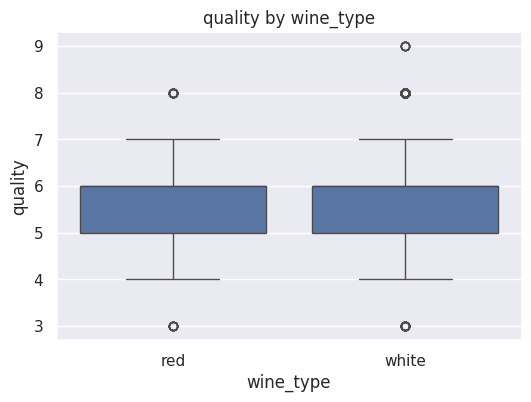

TtestResult(statistic=np.float64(-10.149363059143164), pvalue=np.float64(8.168348870049682e-24), df=np.float64(2950.750452166697))

In [ ]:
# グループに分割
q_red = df.loc[df["wine_type"]=="red", "quality"]
q_white = df.loc[df["wine_type"]=="white", "quality"]

# 箱ひげ図
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="wine_type", y="quality")
plt.title("quality by wine_type")
plt.show()

# Welch t-test
tt = stats.ttest_ind(q_red, q_white, equal_var=False)
tt


t値は平均の差 ÷ 標準誤差であり、それが -10.15 であることから、平均の差は
データのばらつきによるものであるとは考えにくい<br>

自由度（df） ≈ 2951 より標本数が大きいため、小さな差でも有意になりやすい。


In [ ]:
summary = pd.Series({
    "mean_red": q_red.mean(),
    "mean_white": q_white.mean(),
    "diff(red-white)": q_red.mean() - q_white.mean(),
    "p_value": tt.pvalue
})
summary


,0
mean_red,5.636023e+00
mean_white,5.877909e+00
diff(red-white),-2.418868e-01
p_value,8.168349e-24


### 検定の考察
赤ワインの平均品質：約 5.64<br>
白ワインの平均品質：約 5.88<br>
本分析で得られた p 値は 8.17×10^−24と極めて小さく、有意水準 5% はもちろん、1% や 0.1% と比較しても十分に小さい。<br>
このことから、赤ワインと白ワインの品質評価に差がないとする帰無仮説は強く棄却され、
赤ワインと白ワインの品質評価の平均には
統計的に有意な差が存在することが示された。
この差が偶然によって生じた可能性は無視できるほど低い。

したがって、両者の間には何らかの体系的な違いが存在すると考えられるが、
本検定のみから、その差の要因や因果関係を特定することはできない。
この点を明らかにするため、この先で回帰分析を用いて
化学的特性を考慮した検討を行う。


## 【追加課題】 関数を使わず Welch の t 検定
Welch の t 検定を、平均・不偏分散・標本数から t 値と自由度を計算し、t分布のCDFからp値を求めたところ、関数による結果と一致した。<br>
分散の計算には NumPy（np.var）を用い、t 分布の確率計算には SciPy（stats.t.cdf）を用いた。

In [ ]:
red = df.loc[df["wine_type"]=="red", "quality"].to_numpy()
white = df.loc[df["wine_type"]=="white", "quality"].to_numpy()

# 基本統計量
m1, m2 = np.mean(red), np.mean(white)
v1, v2 = np.var(red, ddof=1), np.var(white, ddof=1)
n1, n2 = len(red), len(white)

# Welch t
se = np.sqrt(v1/n1 + v2/n2)
t = (m1 - m2) / se

# Welch-Satterthwaite
df_welch = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))

# 両側p値
p = 2 * (1 - stats.t.cdf(np.abs(t), df=df_welch))

print("mean_red =", m1)
print("mean_white =", m2)
print("diff(red-white) =", m1 - m2)
print("t_value =", t)
print("df =", df_welch)
print("p_value =", p)

mean_red = 5.6360225140712945
mean_white = 5.87790935075541
diff(red-white) = -0.2418868366841158
t_value = -10.149363059143164
df = 2950.750452166697
p_value = 0.0


### 【追加課題】各グループ平均の区間推定

In [ ]:
alpha = 0.05  # 95%CI
# 赤
m1 = np.mean(red)
s1 = np.sqrt(np.var(red, ddof=1))
n1 = len(red)
ci_red = stats.t.interval(
    confidence=1-alpha,
    df=n1-1,
    loc=m1,
    scale=s1/np.sqrt(n1)
)

# 白
m2 = np.mean(white)
s2 = np.sqrt(np.var(white, ddof=1))
n2 = len(white)
ci_white = stats.t.interval(
    confidence=1-alpha,
    df=n2-1,
    loc=m2,
    scale=s2/np.sqrt(n2)
)

print("CI_red (95%) =", ci_red)
print("CI_white (95%) =", ci_white)


CI_red (95%) = (np.float64(5.596409964035299), np.float64(5.67563506410729))
CI_white (95%) = (np.float64(5.853100732289913), np.float64(5.902717969220908))


赤ワインおよび白ワインの品質評価の母平均について、
t 分布に基づく 95% 信頼区間を算出した。<br>
その結果、赤ワインの信頼区間は [5.60, 5.68]、
白ワインの信頼区間は [5.85, 5.90] となり、両者は重ならなかった。<br>

このことから、赤ワインと白ワインの品質評価の平均には
統計的に有意な差が存在することが、
信頼区間の観点からも確認された。


## 4. (3) 正規線形モデル（重回帰 OLS）
品質評価（quality）を被説明変数とし、
ワインの種類（赤・白）および化学的特性を説明変数とする
正規線形モデルを推定した。<br>


quality は整数スコアであり、厳密には連続量や正規分布を仮定する
正規線形モデルの前提を完全には満たさない。<br>
しかし、本課題では変数間の関係を理解することを目的とし、
サンプルサイズも十分に大きいことから、
近似的に OLS（最小二乗法） による正規線形モデルを適用する。<br>

 C(wine_type) の係数は、化学成分を考慮した上での赤ワインと白ワインの平均的な品質差を表しており、カテゴリの違いを数値として扱うために用いた。


In [ ]:
df_model = df.copy()
df_model.columns = df_model.columns.str.replace(" ", "_")

df_model["wine_type"] = df_model["wine_type"].astype("category")

# 11個の説明変数 + wine_type
formula = (
    "quality ~ C(wine_type) + "
    "fixed_acidity + volatile_acidity + citric_acid + residual_sugar + chlorides + "
    "free_sulfur_dioxide + total_sulfur_dioxide + density + pH + sulphates + alcohol"
)

model = smf.ols(formula=formula, data=df_model).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     227.8
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:10:40   Log-Likelihood:                -7195.2
No. Observations:                6497   AIC:                         1.442e+04
Df Residuals:                    6484   BIC:                         1.450e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               104.7518     14.136      7.411      0.000      77.041     132.462
C(wine_type)[T.white]    -0.3613      0.057     -6.367      0.000      -0.473      -0.250
fixed_acidity             0.0851      0.016      5.396      0.000       0.054       0.116
volatile_acidity         -1.4924      0.081    -18.345      0.000      -1.652      -1.333
citric_acid              -0.0626      0.080     -0.786      0.432      -0.219       0.094
residual_sugar            0.0624      0.006     10.522      0.000       0.051       0.074
chlorides                -0.7573      0.334     -2.264      0.024      -1.413      -0.102
free_sulfur_dioxide       0.0049      0.001      6.443      0.000       0.003       0.006
total_sulfur_dioxide     -0.0014      0.000     -4.333      0.000      -0.002      -0.001
density                -103.9096     14.336     -7.248      0.000    -132.013     -75.806
pH                        0.4988      0.091      5.506      0.000       0.321       0.676
sulphates                 0.7217      0.076      9.466      0.000       0.572       0.871
alcohol                   0.2227      0.018     12.320      0.000       0.187       0.258
==============================================================================
Omnibus:                      140.992   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              313.985
Skew:                           0.016   Prob(JB):                     6.59e-69
Kurtosis:                       4.077   Cond. No.                     2.96e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.96e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 回帰係数の解釈

モデル全体について見ると、決定係数は R² = 0.297（調整済み R² = 0.295）であり、本モデルは品質評価の分散の約30%を説明していることが分かる。官能評価という主観的要素を含む指標であることを踏まえると、一定程度の説明力を持つモデルであると考えられる。また、F 検定の結果は有意であり（Prob(F-statistic) < 0.001）、本モデル全体が統計的に意味を持つことが確認された。

次に、ワインの種類を表すダミー変数 C(wine_type)[T.white] の係数は −0.36 程度であり、統計的に有意であった（p < 0.001）。これは、他の化学成分をすべて同じにした条件下では、白ワインは赤ワインに比べて平均的に約0.36ポイント品質評価が低くなることを意味する。よって、本分析で考慮していない要因（未観測の要因、評価の主観的側面など）が評価に影響している可能性が示唆される。

化学成分の影響について見ると、揮発酸（volatile_acidity）は品質評価に対して強い負の影響を持ち、1単位増加すると quality が約1.49低下することが示された。この結果は、揮発酸が多いほど品質評価が低くなるという先行研究の知見と整合的である。一方、アルコール度数（alcohol）は正の影響を持ち、1%増加すると quality が約0.22上昇することが確認された。また、硫酸塩（sulphates）や残糖（residual_sugar）も正の影響を示しており、品質評価との関連が示唆された。クエン酸（citric_acid）は他の変数を考慮すると有意ではなく、独立した影響は確認されなかった。

一方で、本モデルでは条件数（Condition Number）が大きく、多重共線性の可能性が示唆される。特に、密度（density）、アルコール度数、残糖などの変数間には強い相関が存在する可能性があり、係数の大きさや符号の解釈には注意が必要である。
よって次でdensityを外したモデルを考えてみる。


### density を除外したモデル

他の成分と強い相関を持つと考えられる density を除外したモデルを新たに推定した。<br>
その結果、主要な説明変数である揮発酸やアルコール度数の係数の符号や有意性は大きく変化せず、
モデル全体の説明力（R²）も大きく低下しなかった。

このことから、density を含むモデルでは多重共線性の影響により
一部の係数推定が不安定になっている可能性がある一方で、
品質評価と主要成分との関係自体は比較的頑健であることが示唆される。


In [ ]:
formula2 = (
    "quality ~ C(wine_type) + "
    "fixed_acidity + volatile_acidity + citric_acid + residual_sugar + chlorides + "
    "free_sulfur_dioxide + total_sulfur_dioxide + pH + sulphates + alcohol"
)

model2 = smf.ols(formula=formula2, data=df_model).fit()
model2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     241.8
Date:                Thu, 29 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:10:41   Log-Likelihood:                -7221.4
No. Observations:                6497   AIC:                         1.447e+04
Df Residuals:                    6485   BIC:                         1.455e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.3189      0.308      7.522      0.000       1.715       2.923
C(wine_type)[T.white]    -0.1408      0.048     -2.927      0.003      -0.235      -0.046
fixed_acidity            -0.0013      0.010     -0.124      0.901      -0.022       0.019
volatile_acidity         -1.5595      0.081    -19.220      0.000      -1.719      -1.400
citric_acid              -0.0967      0.080     -1.211      0.226      -0.253       0.060
residual_sugar            0.0229      0.002      9.722      0.000       0.018       0.028
chlorides                -1.0040      0.334     -3.006      0.003      -1.659      -0.349
free_sulfur_dioxide       0.0056      0.001      7.332      0.000       0.004       0.007
total_sulfur_dioxide     -0.0018      0.000     -5.478      0.000      -0.002      -0.001
pH                        0.0960      0.072      1.337      0.181      -0.045       0.237
sulphates                 0.5856      0.074      7.894      0.000       0.440       0.731
alcohol                   0.3354      0.009     36.312      0.000       0.317       0.354
==============================================================================
Omnibus:                      138.049   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              303.670
Skew:                           0.024   Prob(JB):                     1.15e-66
Kurtosis:                       4.058   Cond. No.                     5.33e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.33e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

なお、本分析は観察データに基づくものであり、
回帰係数は他の変数を一定とした条件付きの関連を示すに過ぎない。<br>
そのため、特定の化学成分が品質評価を因果的に決定していると
断定することはできない点には留意が必要である。


## 5. model2を用いた新しいワインのqualityを予測
予測に用いる回帰モデルとして、密度（density）を除外した正規線形モデル（model2）を採用した。<br>
これは、全ての説明変数を含むモデルでは Condition Number が非常に大きく、多重共線性の影響により係数推定が不安定になっている可能性が示唆されたためである。

In [ ]:
# 新しいワイン
new_wine = pd.DataFrame([{
    "wine_type": "red",
    "fixed_acidity": 7.4,
    "volatile_acidity": 0.7,
    "citric_acid": 0.0,
    "residual_sugar": 1.9,
    "chlorides": 0.076,
    "free_sulfur_dioxide": 11.0,
    "total_sulfur_dioxide": 34.0,
    "density": 0.9978,
    "pH": 3.51,
    "sulphates": 0.56,
    "alcohol": 9.4
}])

pred = model2.get_prediction(new_wine).summary_frame(alpha=0.05)
pred


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,5.004873,0.030147,4.945774,5.063972,3.560843,6.448902


### 予測の結果・考察

model2 を用いて新しい赤ワインの品質評価を予測した結果、品質の平均的な予測値は 5.00 となった。これは、同様の成分条件を持つワインを多数観測した場合の平均的な品質水準を表している。また、平均予測に対する 95% 信頼区間は [4.95, 5.06] と比較的狭く、モデル係数の推定は安定していることが示唆される。<br>

一方で、個々のワインの品質を表す 95% 予測区間は [3.56, 6.45] と広く、実際の品質評価には大きなばらつきが存在することが分かる。このことから、本モデルは品質の平均的な傾向を捉えることはできるものの、官能評価に含まれる主観的要素や未観測要因の影響により、単一のワインの品質を高精度に予測することには限界があると考えられる。<br>

以上より、多重共線性の影響を考慮して構築した model2 は、解釈性と安定性の点で妥当なモデルであり、ワインの化学成分と品質評価の平均的な関係を把握する目的には適していることが確認された。


## 6. まとめ
- 赤ワインと白ワインの品質評価の平均には統計的に有意な差があり、Welch の t 検定の結果から、この差が偶然によって生じた可能性は極めて低いことが確認された。

- 一方で、回帰分析により化学成分を同時に考慮すると、ワインの種類（赤・白）の影響の解釈は単純な平均比較とは異なることが分かった。成分を統制した条件下では、赤ワインの方が白ワインよりも平均的に高い品質評価を受ける傾向が示唆された。

- 正規線形モデルによる回帰分析の結果、揮発酸（volatile_acidity）は品質評価に対して強い負の影響を持ち、アルコール度数（alcohol）や硫酸塩（sulphates）は正の影響を与えることが確認された。

- 決定係数は約0.30であり、化学成分のみでは品質評価の全てを説明することはできないことが明らかとなった。官能評価には、化学成分以外の要因や主観的なばらつきが大きく影響している可能性が示唆される。

- 説明変数間に多重共線性の可能性が確認され、特に密度（density）は他の成分と強く関連していることが分かった。密度を除外したモデルを用いても主要な結果が大きく変化しなかったことから、品質評価と主要成分との関係は比較的頑健である一方、個々の係数の解釈には注意が必要である。

- 回帰モデルを用いた予測では、平均的な品質水準は比較的安定して推定できたが、個々のワインの品質には大きな不確実性が残ることが確認された。このことから、本モデルは平均的傾向の把握には有効であるものの、単一のワインの品質を高精度に予測する用途には限界があると考えられる。


##発展的な検討・提案

今後の発展的な分析として、説明変数間の相関構造を考慮した主成分回帰や正則化回帰（Ridge 回帰、Lasso 回帰）を用いることで、多重共線性の影響を軽減したモデルの構築が考えられる。

さらに、醸造地域、ブドウ品種、ヴィンテージなどの情報を追加の説明変数として導入することで、化学成分だけでは説明できなかった品質評価のばらつきをより詳細に捉えられる可能性がある。